# Create Modelling Data for GAM
## Setup 
### Import Python Packages 

In [ ]:
# External packages
import pandas as pd
import numpy as np
import sys
from pprint import pprint

# import random
# import os

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Internal packages
sys.path.append("../")
from src import utils

pd.set_option("display.max_columns", 100)

### Set Variables

In [41]:
# Fontsize for visualisation
tick_fontsize = 14
label_fontsize = 18
title_fontsize = 22

# Define the exposure and death counts (both actual and expected)
exposure = "Policies_Exposed"
act_death = "Death_Count"
exp_death = "ExpDth_VBT2015_Cnt"
exp_death_mi = "ExpDth_VBT2015wMI_Cnt"

# Define a dict that maps the counts to rates
count_to_rate_dict = {
    act_death: "act_death_rate", 
    exp_death: "exp_death_rate", 
    exp_death_mi: "exp_death_rate_mi"
} 

# Define holdout and random fold column names 
holdout = "holdout"
random_fold = "random_fold"

# Data
data_file = "export/ILEC_2012_19 - 20240429 (Filtered, Synchronised Attained_Age and Grouped by Selected Features).parquet"

## Create Modelling Data
### Import Data

In [22]:
df_data = pd.read_parquet(data_file)
df_data

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age_Sync,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt
0,2012,M,NS,Term,7,"10: 5,000,000 - 9,999,999",53,4.769294e+08,85.221704,0.0,0.0,0.128005,0.130487
1,2012,M,NS,Term,10,"11: 10,000,000+",59,1.964895e+08,16.607149,0.0,0.0,0.050614,0.051595
2,2012,M,NS,Term,11,"06: 250,000 - 499,999",48,1.988205e+09,6664.746140,2050000.0,8.0,7.494563,7.639922
3,2012,M,NS,Term,7,"04: 50,000 - 99,999",53,1.419839e+07,227.479668,75000.0,1.0,0.341435,0.348057
4,2012,M,NS,Term,6,"02: 10,000 - 24,999",55,2.500000e+05,13.977978,0.0,0.0,0.024675,0.025154
...,...,...,...,...,...,...,...,...,...,...,...,...,...
575749,2015,F,S,Term,19,"01: 0 - 9,999",88,5.109048e+02,0.304110,0.0,0.0,0.038315,0.038315
575750,2019,M,S,Term,24,"07: 500,000 - 999,999",70,1.835616e+05,0.367123,0.0,0.0,0.010632,0.010363
575751,2012,F,S,Term,26,"06: 250,000 - 499,999",68,7.718575e+04,0.308743,0.0,0.0,0.006070,0.006158
575752,2015,M,NS,Term,31,"09: 2,500,000 - 4,999,999",66,2.117475e+05,0.084699,0.0,0.0,0.000713,0.000713


### Map categorical levels to integer values

In [23]:
##################################################################
##################################################################

# Define a list of categorical variables
cat_feat = ["Sex", "Smoker_Status"]

# Define the categorical banding output
output_cat_map = "export/SOA Categorical Mapping.xlsx"

##################################################################
##################################################################

# Save categorical mappings
with pd.ExcelWriter(output_cat_map, engine="openpyxl") as writer:
    for var in cat_feat:
        # Create a dataframe that contains the unique values and their associated integer values
        df_ = pd.DataFrame(df_data[var].unique(), columns=["Categorical_Level"])
        df_.sort_values("Categorical_Level", inplace=True)
        df_["Integer_Value"] = list(range(len(df_)))

        # Save the mapping table
        df_.to_excel(writer, sheet_name=var, index=False)

        # Map the categorical variable into integer values
        df_data[var + "_cat_level"] = df_data[var].map(
            df_.set_index("Categorical_Level").to_dict()["Integer_Value"]
        )

df_data

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age_Sync,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,Sex_cat_level,Smoker_Status_cat_level
0,2012,M,NS,Term,7,"10: 5,000,000 - 9,999,999",53,4.769294e+08,85.221704,0.0,0.0,0.128005,0.130487,1,0
1,2012,M,NS,Term,10,"11: 10,000,000+",59,1.964895e+08,16.607149,0.0,0.0,0.050614,0.051595,1,0
2,2012,M,NS,Term,11,"06: 250,000 - 499,999",48,1.988205e+09,6664.746140,2050000.0,8.0,7.494563,7.639922,1,0
3,2012,M,NS,Term,7,"04: 50,000 - 99,999",53,1.419839e+07,227.479668,75000.0,1.0,0.341435,0.348057,1,0
4,2012,M,NS,Term,6,"02: 10,000 - 24,999",55,2.500000e+05,13.977978,0.0,0.0,0.024675,0.025154,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575749,2015,F,S,Term,19,"01: 0 - 9,999",88,5.109048e+02,0.304110,0.0,0.0,0.038315,0.038315,0,1
575750,2019,M,S,Term,24,"07: 500,000 - 999,999",70,1.835616e+05,0.367123,0.0,0.0,0.010632,0.010363,1,1
575751,2012,F,S,Term,26,"06: 250,000 - 499,999",68,7.718575e+04,0.308743,0.0,0.0,0.006070,0.006158,0,1
575752,2015,M,NS,Term,31,"09: 2,500,000 - 4,999,999",66,2.117475e+05,0.084699,0.0,0.0,0.000713,0.000713,1,0


In [24]:
####################################################################
####################################################################

var = "Sex"
format_dict = {exposure: "{:,.0f}"}
bar_dict = {exposure: "grey"}
caption = f"{var} Distribution"

####################################################################
####################################################################

# Check the distribution of one categorical variable and its integer values 
df_gb = df_data.groupby([var, var + "_cat_level"], dropna=False)[[exposure]].sum()

# Display result
df_gb.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,,Policies_Exposed
Sex,Sex_cat_level,
F,0,"76,248,787"
M,1,"95,530,110"


### Convert Face_Amount_Band into ordinal variable

In [25]:
df_data["Face_Amount_Band_ordinal"] = df_data["Face_Amount_Band"].str[:2].astype(int)
df_data

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age_Sync,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal
0,2012,M,NS,Term,7,"10: 5,000,000 - 9,999,999",53,4.769294e+08,85.221704,0.0,0.0,0.128005,0.130487,1,0,10
1,2012,M,NS,Term,10,"11: 10,000,000+",59,1.964895e+08,16.607149,0.0,0.0,0.050614,0.051595,1,0,11
2,2012,M,NS,Term,11,"06: 250,000 - 499,999",48,1.988205e+09,6664.746140,2050000.0,8.0,7.494563,7.639922,1,0,6
3,2012,M,NS,Term,7,"04: 50,000 - 99,999",53,1.419839e+07,227.479668,75000.0,1.0,0.341435,0.348057,1,0,4
4,2012,M,NS,Term,6,"02: 10,000 - 24,999",55,2.500000e+05,13.977978,0.0,0.0,0.024675,0.025154,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575749,2015,F,S,Term,19,"01: 0 - 9,999",88,5.109048e+02,0.304110,0.0,0.0,0.038315,0.038315,0,1,1
575750,2019,M,S,Term,24,"07: 500,000 - 999,999",70,1.835616e+05,0.367123,0.0,0.0,0.010632,0.010363,1,1,7
575751,2012,F,S,Term,26,"06: 250,000 - 499,999",68,7.718575e+04,0.308743,0.0,0.0,0.006070,0.006158,0,1,6
575752,2015,M,NS,Term,31,"09: 2,500,000 - 4,999,999",66,2.117475e+05,0.084699,0.0,0.0,0.000713,0.000713,1,0,9


In [ ]:
####################################################################
####################################################################

var = "Face_Amount_Band"
format_dict = {exposure: "{:,.0f}"}
bar_dict = {exposure: "grey"}
caption = f"{var} Distribution"

####################################################################
####################################################################

# Check its distribution
df_gb = df_data.groupby([var, var + "_ordinal"], dropna=False)[[exposure]].sum()

# Display result
df_gb.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,,Policies_Exposed
Face_Amount_Band,Face_Amount_Band_ordinal,
"01: 0 - 9,999",1,"667,419"
"02: 10,000 - 24,999",2,"1,781,149"
"03: 25,000 - 49,999",3,"3,851,687"
"04: 50,000 - 99,999",4,"9,761,772"
"05: 100,000 - 249,999",5,"49,977,922"
"06: 250,000 - 499,999",6,"48,617,431"
"07: 500,000 - 999,999",7,"34,883,958"
"08: 1,000,000 - 2,499,999",8,"20,217,409"
"09: 2,500,000 - 4,999,999",9,"1,446,823"


### Define Training/Holdout Sets and Random Folds

In [29]:
# Set the last two observation years as the holdout
df_data[holdout] = np.where(df_data["Observation_Year"].isin([2018, 2019]), 1, 0)
df_data

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age_Sync,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal,holdout
0,2012,M,NS,Term,7,"10: 5,000,000 - 9,999,999",53,4.769294e+08,85.221704,0.0,0.0,0.128005,0.130487,1,0,10,0
1,2012,M,NS,Term,10,"11: 10,000,000+",59,1.964895e+08,16.607149,0.0,0.0,0.050614,0.051595,1,0,11,0
2,2012,M,NS,Term,11,"06: 250,000 - 499,999",48,1.988205e+09,6664.746140,2050000.0,8.0,7.494563,7.639922,1,0,6,0
3,2012,M,NS,Term,7,"04: 50,000 - 99,999",53,1.419839e+07,227.479668,75000.0,1.0,0.341435,0.348057,1,0,4,0
4,2012,M,NS,Term,6,"02: 10,000 - 24,999",55,2.500000e+05,13.977978,0.0,0.0,0.024675,0.025154,1,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575749,2015,F,S,Term,19,"01: 0 - 9,999",88,5.109048e+02,0.304110,0.0,0.0,0.038315,0.038315,0,1,1,0
575750,2019,M,S,Term,24,"07: 500,000 - 999,999",70,1.835616e+05,0.367123,0.0,0.0,0.010632,0.010363,1,1,7,1
575751,2012,F,S,Term,26,"06: 250,000 - 499,999",68,7.718575e+04,0.308743,0.0,0.0,0.006070,0.006158,0,1,6,0
575752,2015,M,NS,Term,31,"09: 2,500,000 - 4,999,999",66,2.117475e+05,0.084699,0.0,0.0,0.000713,0.000713,1,0,9,0


In [32]:
#####################################################################################
#####################################################################################

seed = 2026
num_fold = 5

#####################################################################################
#####################################################################################

# Define a column for random folds for cross validations
np.random.seed(seed)
df_data[random_fold] = np.random.randint(1, num_fold + 1, len(df_data))
df_data[random_fold] = np.where(
    df_data[holdout] == 0, df_data[random_fold], num_fold + 1
)
df_data

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age_Sync,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal,holdout,random_fold
0,2012,M,NS,Term,7,"10: 5,000,000 - 9,999,999",53,4.769294e+08,85.221704,0.0,0.0,0.128005,0.130487,1,0,10,0,2
1,2012,M,NS,Term,10,"11: 10,000,000+",59,1.964895e+08,16.607149,0.0,0.0,0.050614,0.051595,1,0,11,0,3
2,2012,M,NS,Term,11,"06: 250,000 - 499,999",48,1.988205e+09,6664.746140,2050000.0,8.0,7.494563,7.639922,1,0,6,0,1
3,2012,M,NS,Term,7,"04: 50,000 - 99,999",53,1.419839e+07,227.479668,75000.0,1.0,0.341435,0.348057,1,0,4,0,5
4,2012,M,NS,Term,6,"02: 10,000 - 24,999",55,2.500000e+05,13.977978,0.0,0.0,0.024675,0.025154,1,0,2,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575749,2015,F,S,Term,19,"01: 0 - 9,999",88,5.109048e+02,0.304110,0.0,0.0,0.038315,0.038315,0,1,1,0,1
575750,2019,M,S,Term,24,"07: 500,000 - 999,999",70,1.835616e+05,0.367123,0.0,0.0,0.010632,0.010363,1,1,7,1,6
575751,2012,F,S,Term,26,"06: 250,000 - 499,999",68,7.718575e+04,0.308743,0.0,0.0,0.006070,0.006158,0,1,6,0,1
575752,2015,M,NS,Term,31,"09: 2,500,000 - 4,999,999",66,2.117475e+05,0.084699,0.0,0.0,0.000713,0.000713,1,0,9,0,3


In [46]:
####################################################################
####################################################################

var = [random_fold, holdout]

format_dict = {
    exposure: "{:,.0f}",
    **{k: "{:,.0f}" for k, _ in count_to_rate_dict.items()},
    **{v: "{:,.4%}" for _, v in count_to_rate_dict.items()},
}
bar_dict = {
    exposure: "grey",
    **{v: "grey" for k, _ in count_to_rate_dict.items()},
    **{v: "blue" for _, v in count_to_rate_dict.items()},
}
caption = f"{var} Distribution"

####################################################################
####################################################################

# Check its distribution and the actual and expected death rates
df_gb = df_data.groupby(var, dropna=False)[
    [exposure, act_death, exp_death, exp_death_mi]
].sum()

for k, v in count_to_rate_dict.items():
    df_gb[v] = df_gb[k] / df_gb[exposure]

# Display result
df_gb.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,,Policies_Exposed,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,act_death_rate,exp_death_rate,exp_death_rate_mi
random_fold,holdout,,,,,,,
1,0,"24,768,430","49,073","44,079","44,154",0.1981%,0.1780%,0.1783%
2,0,"25,151,101","49,355","44,683","44,754",0.1962%,0.1777%,0.1779%
3,0,"24,833,929","49,512","45,487","45,556",0.1994%,0.1832%,0.1834%
4,0,"24,818,144","48,656","44,432","44,504",0.1961%,0.1790%,0.1793%
5,0,"24,858,380","49,663","45,346","45,420",0.1998%,0.1824%,0.1827%
6,1,"47,348,914","113,892","108,484","106,304",0.2405%,0.2291%,0.2245%


### Create normalised target variables
PyGAM doesn't have an offset functionality, hence the need to create actual and expected death rates. 

In [52]:
for k, v in count_to_rate_dict.items(): 
    df_data[v] = df_data[k] / df_data[exposure]
df_data

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age_Sync,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal,holdout,random_fold,act_death_rate,exp_death_rate,exp_death_rate_mi
0,2012,M,NS,Term,7,"10: 5,000,000 - 9,999,999",53,4.769294e+08,85.221704,0.0,0.0,0.128005,0.130487,1,0,10,0,2,0.000000,0.001502,0.001531
1,2012,M,NS,Term,10,"11: 10,000,000+",59,1.964895e+08,16.607149,0.0,0.0,0.050614,0.051595,1,0,11,0,3,0.000000,0.003048,0.003107
2,2012,M,NS,Term,11,"06: 250,000 - 499,999",48,1.988205e+09,6664.746140,2050000.0,8.0,7.494563,7.639922,1,0,6,0,1,0.001200,0.001125,0.001146
3,2012,M,NS,Term,7,"04: 50,000 - 99,999",53,1.419839e+07,227.479668,75000.0,1.0,0.341435,0.348057,1,0,4,0,5,0.004396,0.001501,0.001530
4,2012,M,NS,Term,6,"02: 10,000 - 24,999",55,2.500000e+05,13.977978,0.0,0.0,0.024675,0.025154,1,0,2,0,5,0.000000,0.001765,0.001800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575749,2015,F,S,Term,19,"01: 0 - 9,999",88,5.109048e+02,0.304110,0.0,0.0,0.038315,0.038315,0,1,1,0,1,0.000000,0.125990,0.125990
575750,2019,M,S,Term,24,"07: 500,000 - 999,999",70,1.835616e+05,0.367123,0.0,0.0,0.010632,0.010363,1,1,7,1,6,0.000000,0.028960,0.028228
575751,2012,F,S,Term,26,"06: 250,000 - 499,999",68,7.718575e+04,0.308743,0.0,0.0,0.006070,0.006158,0,1,6,0,1,0.000000,0.019660,0.019945
575752,2015,M,NS,Term,31,"09: 2,500,000 - 4,999,999",66,2.117475e+05,0.084699,0.0,0.0,0.000713,0.000713,1,0,9,0,3,0.000000,0.008420,0.008420


### Set Unique ID

In [56]:
df_data.index.name = "unique_id"
df_data

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age_Sync,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal,holdout,random_fold,act_death_rate,exp_death_rate,exp_death_rate_mi
unique_id,,,,,,,,,,,,,,,,,,,,,
0,2012,M,NS,Term,7,"10: 5,000,000 - 9,999,999",53,4.769294e+08,85.221704,0.0,0.0,0.128005,0.130487,1,0,10,0,2,0.000000,0.001502,0.001531
1,2012,M,NS,Term,10,"11: 10,000,000+",59,1.964895e+08,16.607149,0.0,0.0,0.050614,0.051595,1,0,11,0,3,0.000000,0.003048,0.003107
2,2012,M,NS,Term,11,"06: 250,000 - 499,999",48,1.988205e+09,6664.746140,2050000.0,8.0,7.494563,7.639922,1,0,6,0,1,0.001200,0.001125,0.001146
3,2012,M,NS,Term,7,"04: 50,000 - 99,999",53,1.419839e+07,227.479668,75000.0,1.0,0.341435,0.348057,1,0,4,0,5,0.004396,0.001501,0.001530
4,2012,M,NS,Term,6,"02: 10,000 - 24,999",55,2.500000e+05,13.977978,0.0,0.0,0.024675,0.025154,1,0,2,0,5,0.000000,0.001765,0.001800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575749,2015,F,S,Term,19,"01: 0 - 9,999",88,5.109048e+02,0.304110,0.0,0.0,0.038315,0.038315,0,1,1,0,1,0.000000,0.125990,0.125990
575750,2019,M,S,Term,24,"07: 500,000 - 999,999",70,1.835616e+05,0.367123,0.0,0.0,0.010632,0.010363,1,1,7,1,6,0.000000,0.028960,0.028228
575751,2012,F,S,Term,26,"06: 250,000 - 499,999",68,7.718575e+04,0.308743,0.0,0.0,0.006070,0.006158,0,1,6,0,1,0.000000,0.019660,0.019945


### Correlation Matrix

[Text(0.5, 0, 'act_death_rate'),
 Text(1.5, 0, 'exp_death_rate'),
 Text(2.5, 0, 'exp_death_rate_mi'),
 Text(3.5, 0, 'Observation_Year'),
 Text(4.5, 0, 'Duration'),
 Text(5.5, 0, 'Attained_Age_Sync'),
 Text(6.5, 0, 'Face_Amount_Band_ordinal'),
 Text(7.5, 0, 'Sex_cat_level'),
 Text(8.5, 0, 'Smoker_Status_cat_level')]

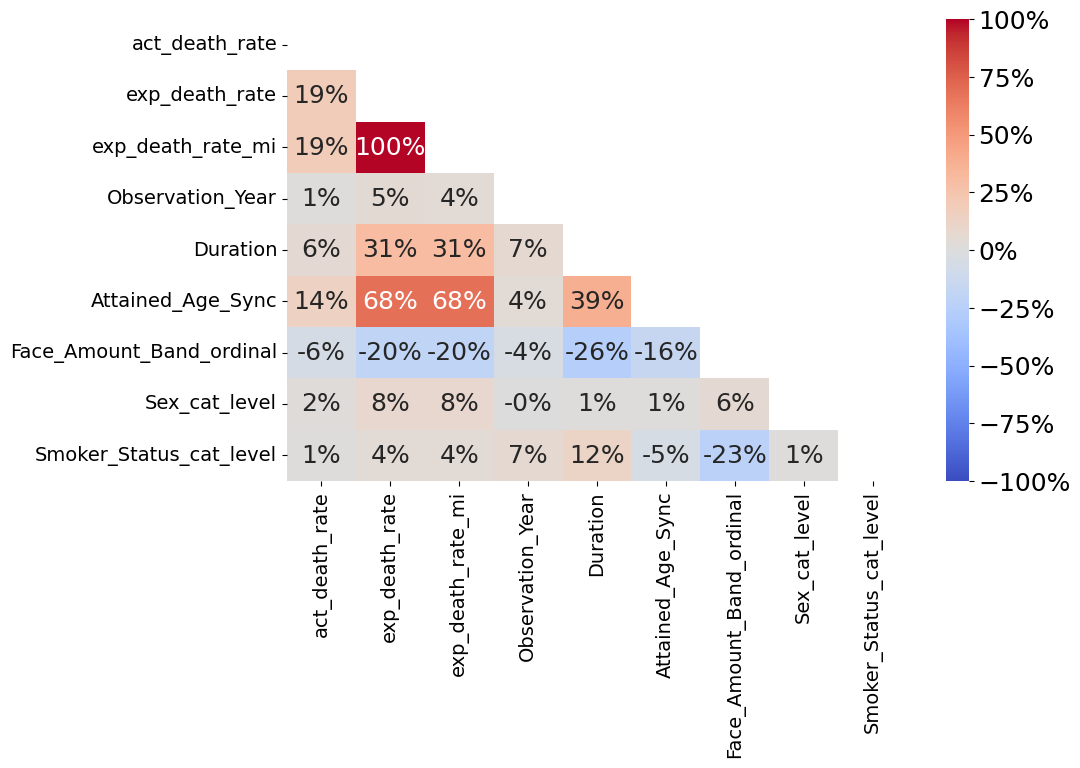

In [57]:
##########################################################################
##########################################################################

# Define a list of column names in-scope for correlation analysis
col_for_corr_list = [
    *[v for _, v in count_to_rate_dict.items()],
    "Observation_Year",
    "Duration",
    "Attained_Age_Sync",
    "Face_Amount_Band_ordinal",
    *[x + "_cat_level" for x in cat_feat],
]

##########################################################################
##########################################################################

corr_mat = round(df_data[col_for_corr_list].corr(), 2)

# Fill diagonal and upper half with NaNs
mask = np.zeros_like(corr_mat, dtype=bool)
mask[np.triu_indices_from(mask)] = True
corr_mat[mask] = np.nan

fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.heatmap(
    corr_mat,
    annot=True,
    annot_kws={"size": label_fontsize},
    fmt=".0%",
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

colorbar = ax.collections[0].colorbar
colorbar.ax.tick_params(labelsize=label_fontsize)
colorbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))

ax.set_facecolor("white")
ax.set_yticklabels(df_data[col_for_corr_list].columns, fontsize=tick_fontsize)
ax.set_xticklabels(df_data[col_for_corr_list].columns, fontsize=tick_fontsize)

## Export files

In [58]:
###########################################################################
###########################################################################

model_data_output = "export/Modelling_data (Filtered, Synchronised Attained_Age and Grouped by Selected Features).parquet"

###########################################################################
###########################################################################

df_data.to_parquet(
    f"{model_data_output}",
    engine="pyarrow",
    compression="gzip",
)